In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\MVSR\Documents\ml 23-311\cirrhosis.csv")
print(df.head())
print(df.info())

   ID  Age Sex  Bilirubin  Albumin  Copper  SGOT  Platelets  Prothrombin  \
0   1   68   M       5.07     4.16     115   125        332         11.4   
1   2   58   F       2.09     2.92     145   314        404          9.2   
2   3   44   M       5.54     3.63     137   333        113         13.5   
3   4   72   F      13.63     3.53      67   255        242         13.3   
4   5   37   F       4.30     3.91     108   272        100         16.5   

            Status  
0          Healthy  
1  Early_Cirrhosis  
2          Healthy  
3  Early_Cirrhosis  
4  Early_Cirrhosis  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           100 non-null    int64  
 1   Age          100 non-null    int64  
 2   Sex          100 non-null    object 
 3   Bilirubin    100 non-null    float64
 4   Albumin      100 non-null    float64
 5   Copper       1

In [3]:
print(df.isnull().sum())

ID             0
Age            0
Sex            0
Bilirubin      0
Albumin        0
Copper         0
SGOT           0
Platelets      0
Prothrombin    0
Status         0
dtype: int64


   ID  Age Sex  Bilirubin  Albumin  Copper  SGOT  Platelets  Prothrombin  \
0   1   68   M       5.07     4.16     115   125        332         11.4   
1   2   58   F       2.09     2.92     145   314        404          9.2   
2   3   44   M       5.54     3.63     137   333        113         13.5   
3   4   72   F      13.63     3.53      67   255        242         13.3   
4   5   37   F       4.30     3.91     108   272        100         16.5   

            Status  
0          Healthy  
1  Early_Cirrhosis  
2          Healthy  
3  Early_Cirrhosis  
4  Early_Cirrhosis  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           100 non-null    int64  
 1   Age          100 non-null    int64  
 2   Sex          100 non-null    object 
 3   Bilirubin    100 non-null    float64
 4   Albumin      100 non-null    float64
 5   Copper       1

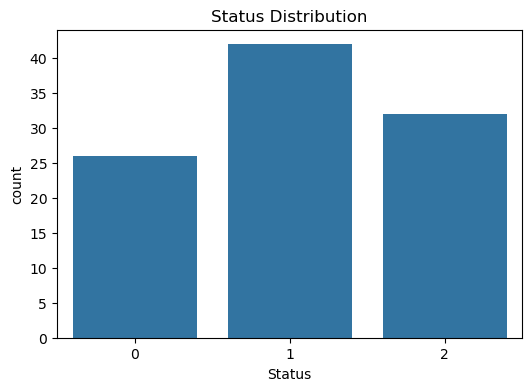

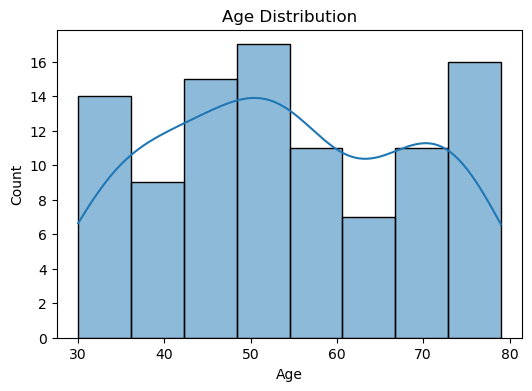

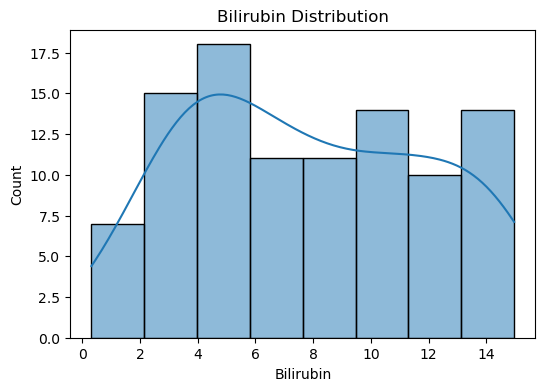

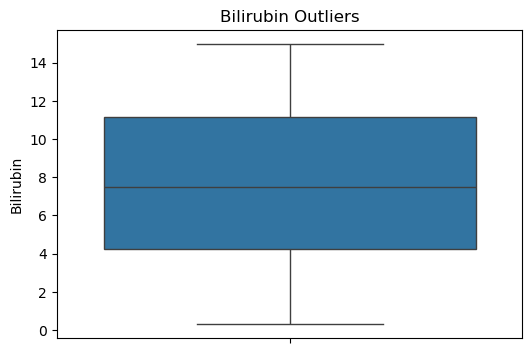

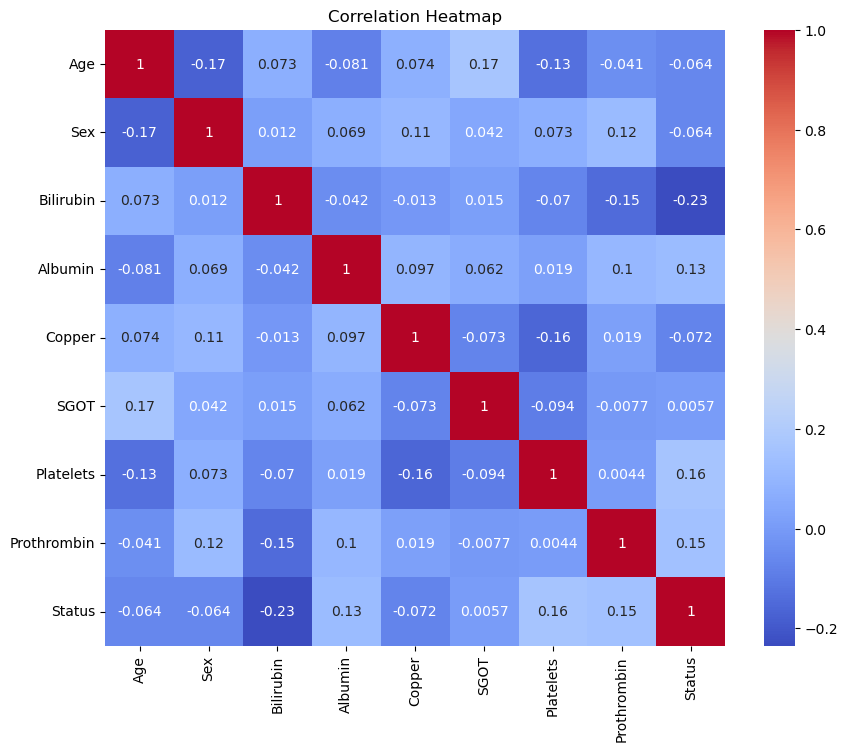

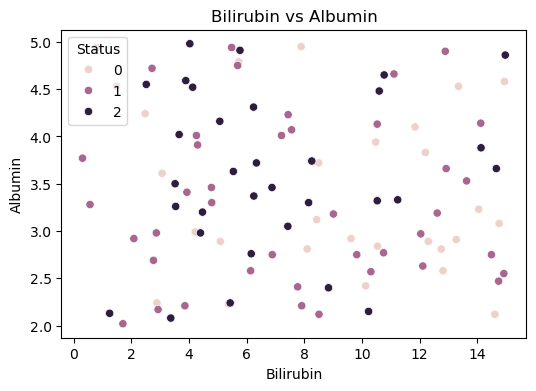

In [12]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\MVSR\Documents\ml 23-311\cirrhosis.csv")

# Display first 5 rows
print(df.head())

# Dataset Information
print(df.info())

# Check Missing Values
print(df.isnull().sum())

# -----------------------------
# DATA PREPROCESSING
# -----------------------------

# Fill Missing Values
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove ID column
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("\nAfter Preprocessing:")
print(df.head())

# -----------------------------
# EDA
# -----------------------------

# Dataset Shape
print("Dataset Shape:", df.shape)

# Statistical Summary
print(df.describe())

# Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.title("Status Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Bilirubin Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Bilirubin'], kde=True)
plt.title("Bilirubin Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Bilirubin'])
plt.title("Bilirubin Outliers")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Bilirubin',
    y='Albumin',
    hue='Status',
    data=df
)
plt.title("Bilirubin vs Albumin")
plt.show()